In [2]:
%load_ext autoreload
%autoreload 2

%aimport -numpy
%aimport -sympy
%aimport -scipy
%aimport -matplotlib

from pathlib import Path
import numpy as np

from Data.Primitives.environment_classes import Drone, Radar, Context
from Data.Primitives.noise_models import AdditiveWhiteGaussianNoise, BaseNoiseModel
from Data.Primitives.presets import *

from Data.Generators.synthetic_signal_generator import SyntheticSignalGenerator
from Data.Generators.synthetic_dataset_generator import DatasetMetadata, DataRequest, SyntheticDatasetGenerator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generating samples

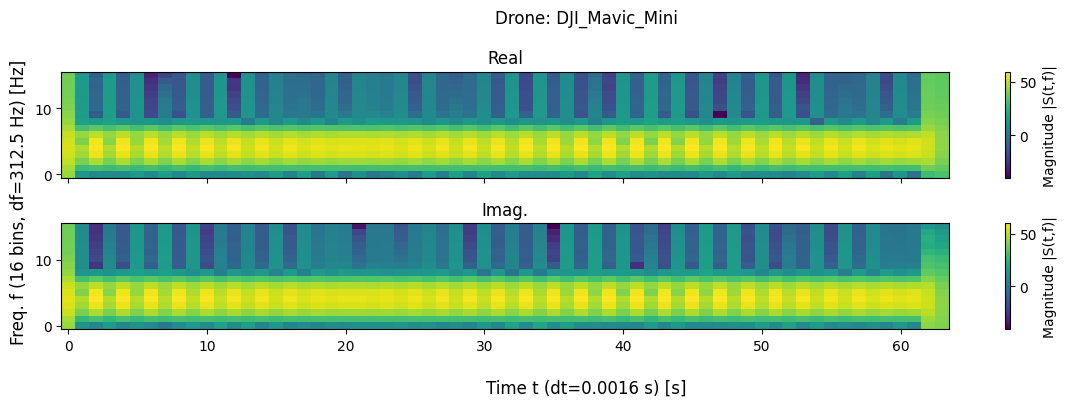

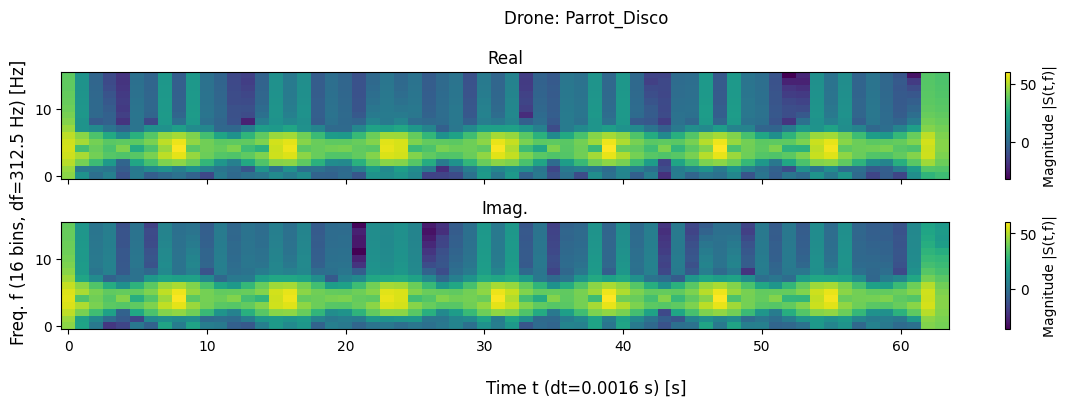

In [3]:
context = Context(
    R = 1000,
    V_rad = 25,
    θ = np.pi/8,
    Φ_p = np.pi/8,
    A_r = 1,
    snr = 20,
    t_start = 0,
    t_stop = 0.1,
    dt = 0.0001
)

awgn = AdditiveWhiteGaussianNoise()
for drone in drones_array:
    synt_signal_generator = SyntheticSignalGenerator(drone, default_radar, awgn)
    t_array,stft_y = synt_signal_generator.generate_signal(context)
    synt_signal_generator.plot_drone_spectrogram(stft_y, context)

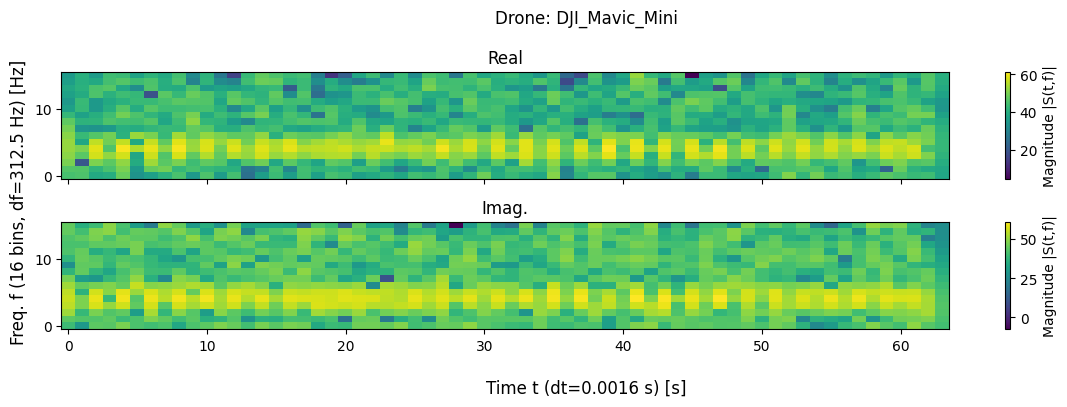

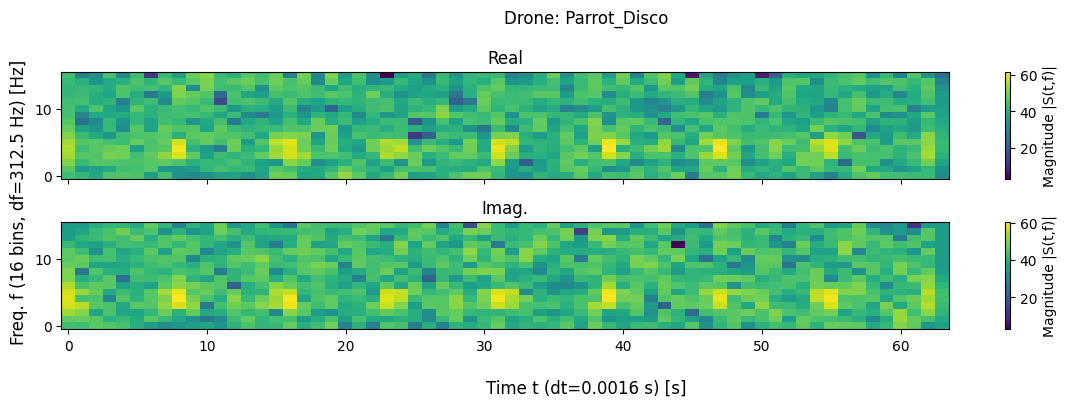

In [4]:
context = Context(
    R = 1000,
    V_rad = 25,
    θ = np.pi/8,
    Φ_p = np.pi/8,
    A_r = 1,
    snr = -60,
    t_start = 0,
    t_stop = 0.1,
    dt = 0.0001
)

awgn = AdditiveWhiteGaussianNoise()
for drone in drones_array:
    synt_signal_generator = SyntheticSignalGenerator(drone, default_radar, awgn)
    t_array,stft_y = synt_signal_generator.generate_signal(context)
    synt_signal_generator.plot_drone_spectrogram(stft_y, context)

# Generation of datasets

## 1. Time domain datasets

### Training dataset

In [6]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "Datasets" / "time_domain" / "training_dataset.pkl"
md = DatasetMetadata.create_from_path(path)

snr_values = np.arange(-50,20,5)
different_sample_size = 70
sample_sample_size = 1
t_len = 0.1
dt = 0.0001

contexts_array = []
for snr in snr_values:
    for _ in range(different_sample_size):
        contexts_array.append(Context(
            R = np.random.uniform(low=200, high=2000),
            V_rad = np.random.uniform(low=0, high=50),
            θ = np.random.uniform(low=np.pi/16, high=np.pi/2),
            Φ_p = np.random.uniform(low=0, high=np.pi/4),
            A_r = np.random.chisquare(4),
            snr = snr,
            t_start = 0,
            t_stop = t_len,
            dt = dt
        ))


data_requests_array = []
for cont in contexts_array:
    for drone in drones_array:
        data_req = DataRequest(
            request_name    = f"label={drone.name}",
            drone           = drone,
            radar           = default_radar,
            context         = cont,
            noise_model     = AdditiveWhiteGaussianNoise(),
            sample_size     = sample_sample_size
        )
        data_requests_array.append(data_req)

dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
# dataset_gen.set_noise_samples(n=sample_size*len(contexts_array),t_len=t_len ,dt=dt)
dataset_gen.generate_signal_data(stft_form=False)

Signal samples: 100%|██████████| 1960/1960 [00:24<00:00, 78.45it/s]


### Validating dataset

In [7]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "Datasets" / "time_domain" / "validating_dataset.pkl"
md = DatasetMetadata.create_from_path(path)

different_sample_size = 20
same_sample_size = 1

contexts_array = []
for snr in snr_values:
    for _ in range(different_sample_size):
        contexts_array.append(Context(
            R = np.random.uniform(low=200, high=2000),
            V_rad = np.random.uniform(low=0, high=50),
            θ = np.random.uniform(low=np.pi/16, high=np.pi/2),
            Φ_p = np.random.uniform(low=0, high=np.pi/4),
            A_r = np.random.chisquare(4),
            snr = snr,
            t_start = 0,
            t_stop = t_len,
            dt = dt
        ))

data_requests_array = []
for cont in contexts_array:
    for drone in drones_array:
        data_req = DataRequest(
            request_name    = f"label={drone.name}",
            drone           = drone,
            radar           = default_radar,
            context         = cont,
            noise_model     = AdditiveWhiteGaussianNoise(),
            sample_size     = same_sample_size
        )
        data_requests_array.append(data_req)

dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
# dataset_gen.set_noise_samples(n=sample_size*len(contexts_array),t_len=t_len ,dt=dt)
dataset_gen.generate_signal_data(stft_form=False)

Signal samples: 100%|██████████| 560/560 [00:07<00:00, 78.64it/s]


### Testing dataset

In [8]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "Datasets" / "time_domain" / "testing_dataset.pkl"
md = DatasetMetadata.create_from_path(path)

different_sample_size = 10
same_sample_size = 1

contexts_array = []
for snr in snr_values:
    for _ in range(different_sample_size):
        contexts_array.append(Context(
            R = np.random.uniform(low=200, high=2000),
            V_rad = np.random.uniform(low=0, high=50),
            θ = np.random.uniform(low=np.pi/16, high=np.pi/2),
            Φ_p = np.random.uniform(low=0, high=np.pi/4),
            A_r = np.random.chisquare(4),
            snr = snr,
            t_start = 0,
            t_stop = t_len,
            dt = dt
        ))

data_requests_array = []
for cont in contexts_array:
    for drone in drones_array:
        data_req = DataRequest(
            request_name    = f"label={drone.name}",
            drone           = drone,
            radar           = default_radar,
            context         = cont,
            noise_model     = AdditiveWhiteGaussianNoise(),
            sample_size     = same_sample_size
        )
        data_requests_array.append(data_req)

dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
# dataset_gen.set_noise_samples(n=sample_size*len(contexts_array),t_len=t_len ,dt=dt)
dataset_gen.generate_signal_data(stft_form=False)

Signal samples: 100%|██████████| 280/280 [00:03<00:00, 71.84it/s]


## 2. Frequency domain data

### Training dataset

In [5]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "Datasets" / "frequency_domain" / "training_dataset.pkl"
md = DatasetMetadata.create_from_path(path)

snr_values = np.arange(-15,20,5)
sample_size = 70
t_len = 0.1
dt = 0.0001

contexts_array = []
for snr in snr_values:
    contexts_array.append(Context(
        R = np.random.uniform(low=200, high=2000),
        V_rad = np.random.uniform(low=0, high=50),
        θ = np.random.uniform(low=np.pi/16, high=np.pi/2),
        Φ_p = np.random.uniform(low=0, high=np.pi/4),
        A_r = np.random.chisquare(4),
        snr = snr,
        t_start = 0,
        t_stop = t_len,
        dt = dt
    ))


data_requests_array = []
for cont in contexts_array:
    for drone in drones_array:
        data_req = DataRequest(
            request_name    = f"label={drone.name}",
            drone           = drone,
            radar           = default_radar,
            context         = cont,
            noise_model     = AdditiveWhiteGaussianNoise(),
            sample_size     = sample_size
        )
        data_requests_array.append(data_req)

dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
dataset_gen.set_noise_samples(n=sample_size*len(contexts_array),t_len=t_len ,dt=dt)
dataset_gen.generate_signal_data(stft_form=True)

Noise samples: 100%|██████████| 490/490 [00:00<00:00, 1628.60it/s]


### Validating dataset

In [6]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "Datasets" / "frequency_domain" / "validating_dataset.pkl"
md = DatasetMetadata.create_from_path(path)

sample_size = 20

data_requests_array = []
for cont in contexts_array:
    for drone in drones_array:
        data_req = DataRequest(
            request_name    = f"label={drone.name}",
            drone           = drone,
            radar           = default_radar,
            context         = cont,
            noise_model     = AdditiveWhiteGaussianNoise(),
            sample_size     = sample_size
        )
        data_requests_array.append(data_req)

dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
dataset_gen.set_noise_samples(n=sample_size*len(contexts_array),t_len=t_len ,dt=dt)
dataset_gen.generate_signal_data(stft_form=True)

Noise samples: 100%|██████████| 140/140 [00:00<00:00, 1637.17it/s]


### Testing dataset

In [7]:
PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT  / "Datasets" / "frequency_domain" / "testing_dataset.pkl"
md = DatasetMetadata.create_from_path(path)

sample_size = 10

data_requests_array = []
for cont in contexts_array:
    for drone in drones_array:
        data_req = DataRequest(
            request_name    = f"label={drone.name}",
            drone           = drone,
            radar           = default_radar,
            context         = cont,
            noise_model     = AdditiveWhiteGaussianNoise(),
            sample_size     = sample_size
        )
        data_requests_array.append(data_req)

dataset_gen = SyntheticDatasetGenerator(dataset_metadata=md)
dataset_gen.append_data_requests(data_requests=data_requests_array)
dataset_gen.set_noise_samples(n=sample_size*len(contexts_array),t_len=t_len ,dt=dt)
dataset_gen.generate_signal_data(stft_form=True)

Noise samples: 100%|██████████| 70/70 [00:00<00:00, 1709.42it/s]
